# 03 - Language detection and the final dataset  (Req 6)

**Goal:** label each tweet's language, flag possible code-switching, and produce the final dataset for the team.

The work is done by `src/03_detect_language.py`, which takes **10-15 minutes** for 100k tweets. So this notebook loads the saved result by default; set `RERUN = True` in the first cell to run the detection again.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', 110)
pd.set_option('display.width', 200)

RERUN = False   # True = run the detection again (10-15 minutes). False = just load the saved result.
if RERUN:
    %run ../src/03_detect_language.py

## Load the final dataset
This is exactly what teammates will load.

In [2]:
df = pd.read_parquet('../data/processed/nampulse_clean.parquet')
print(df.shape)
df.head(5)

(100493, 16)


,tweet_id,created_at,label,label_source,topic_group,text_raw,text_clean,language,language_conf,is_english,is_code_switched,languages_found,other_lang_words,dup_group_size,n_words,text_key
0,1467815753,2009-04-07 05:21:04+00:00,negative,emoticon,unknown,Meh... Almost Lover is the exception... this track gets me depressed every time.,Meh... Almost Lover is the exception... this track gets me depressed every time.,en,0.944,True,False,en,0,1,13,meh almost lover is the exception this track gets me depressed every time
1,1467815924,2009-04-07 05:21:07+00:00,negative,emoticon,unknown,@alielayus I want to go to promote GEAR AND GROOVE but unfornately no ride there I may b going to the one...,I want to go to promote GEAR AND GROOVE but unfornately no ride there I may b going to the one in Anaheim ...,en,0.986,True,False,en,0,1,26,i want to go to promote gear and groove but unfornately no ride there i may b going to the one in anaheim ...
2,1467821338,2009-04-07 05:22:30+00:00,negative,emoticon,unknown,"Put vacation photos online a few yrs ago. PC crashed, and now I forget the name of the site.","Put vacation photos online a few yrs ago. PC crashed, and now I forget the name of the site.",en,0.969,True,False,en,0,1,19,put vacation photos online a few yrs ago pc crashed and now i forget the name of the site
3,1467822489,2009-04-07 05:22:49+00:00,positive,emoticon,unknown,"@tommcfly ah, congrats mr fletcher for finally joining twitter","ah, congrats mr fletcher for finally joining twitter",en,0.913,True,False,en,0,1,8,ah congrats mr fletcher for finally joining twitter
4,1467822899,2009-04-07 05:22:58+00:00,positive,emoticon,unknown,@michellardi i really don't know. i think its Globe! yeah! sana gumaling na ko para alam ko na din kung m...,i really don't know. i think its Globe! yeah! sana gumaling na ko para alam ko na din kung makakasama ako! ),tl,0.762,False,True,tl|en,4,1,22,i really don t know i think its globe yeah sana gumaling na ko para alam ko na din kung makakasama ako


## Language overview

language
en     93146
und     7208
ru        19
tl        17
vi        10
de         9
id         9
ro         9
ko         6
ms         5
nl         5
pt         4
zh         4
tr         4
es         4
sv         3
ja         3
fr         3
th         3
ts         2
ar         2
hu         2
cs         2
et         2
cy         2
da         1
tn         1
la         1
uk         1
ta         1
mk         1
he         1
el         1
st         1
ca         1
Name: count, dtype: int64


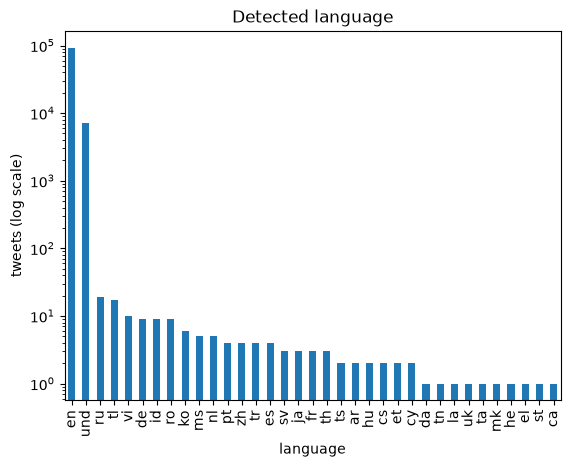

In [3]:
print(df['language'].value_counts())
df['language'].value_counts().plot.bar(title='Detected language', logy=True)
plt.ylabel('tweets (log scale)'); plt.show()

## Non-English tweets that were detected
These are the tweets Req 6 is about. Check them by eye - short informal text makes detectors make mistakes.

In [4]:
other = df[(~df['is_english']) & (df['language'] != 'und')]
print(len(other), 'tweets detected as a non-English language')
other.sort_values('language_conf', ascending=False)[['text_clean', 'language', 'language_conf']].groupby('language').head(2).head(12)

139 tweets detected as a non-English language


,text_clean,language,language_conf
50883,실지 티스토리 ? 매 ? 담벽 (Firewall) ? 넘어서 글 올리고 있습니다. 얘긴 안해서 그렇지 짜 ?나긴 짜 ?납니다,ko,1.0
49974,? りゃ ?ホント ? ? ? 。短 ? エントリ ? ウケ ? ? ?,ja,1.0
52887,my naathanaa & kidz.. I'm xtra க ?ட ?ம ?பத ?த ? க ?த ?த ? விளக ?க ? for a week,ta,1.0
58595,Cool! 我家有CBS， ? 以看Tony Award........開心開心開心,zh,1.0
55935,หรือไม่ ?็น่าจะโดน hack twitter,th,1.0
44995,"thằng nó khen điệp mà, chứ có khen đẹp đâu !",vi,1.0
50316,暑 ?? ? ? ? ?? ? ?油断 ? る ? ? ? ? 虫 ? 入 ? ? ?? ? 飛 ? 回る ? よ ? ? 〜,ja,1.0
50818,หลังติดตั้ง ?ล้วผมเปลี่ยน ?ลับเป็นภาษาอัง ?ฤษได้หมดนะ (Admin > Language Support) ?ต่ป ?ติผมใช้ภาษาไทย,th,1.0
43092,앗 그냥 self_intro 붙 ? 고 소개 ?으시면 제가 Search 봇 ? 려서 ? ? 으로 소개페 ? 지 ? 추가할것입니다. 참고하셔서 멋지게 ?어보세요,ko,1.0
43639,thinks 女生總是覺得男孩 ? ? 是為自己，顧自己； ? 是，男孩 ?其實經已負出了 ? ?給女生說．．．,zh,1.0


## Why "und" (undetermined)?
Mostly very short or noisy tweets, where any detector is unreliable. We say "und" rather than guess.

In [5]:
und = df[df['language'] == 'und']
print('und tweets:', len(und), '| median words:', und['n_words'].median(), 'vs English:', df[df['is_english']]['n_words'].median())
und[['text_clean', 'language_conf']].sample(8, random_state=1)

und tweets: 7208 | median words: 3.0 vs English: 12.0


,text_clean,language_conf
61865,I was up at 4:00 haha,0.074
33902,told you,0.000
77673,my stomach hurts,0.240
58850,Dinner for my gpa's 91st bday!,0.107
55790,Weellll you'll get to meet her anyway! Yay!!! Lol yaaay for allowance! HAHA,0.475
4879,On my Wii Fit Yoga is fun,0.061
21981,"thanks, brends!",0.000
19498,*waving*,0.000


## How does language affect sentiment? (Req 6 asks us to report this)
Compare the label mix for English vs the rest. Neutral only exists in the small hand-labelled part, so it barely shows up here.

label     negative  neutral  positive  tweets
language                                     
en            50.4      0.1      49.5   93146
und           40.6      0.2      59.2    7208
ru            15.8      0.0      84.2      19
tl            58.8      0.0      41.2      17
vi            50.0      0.0      50.0      10
id            44.4      0.0      55.6       9
de            22.2      0.0      77.8       9
ro            11.1      0.0      88.9       9
ko             0.0      0.0     100.0       6
nl            20.0      0.0      80.0       5
ms            80.0      0.0      20.0       5
pt            50.0      0.0      50.0       4
es           100.0      0.0       0.0       4
zh            50.0      0.0      50.0       4
tr            25.0      0.0      75.0       4
fr            33.3      0.0      66.7       3
sv            33.3      0.0      66.7       3
th            33.3      0.0      66.7       3
ja            33.3      0.0      66.7       3
cy            50.0      0.0      5

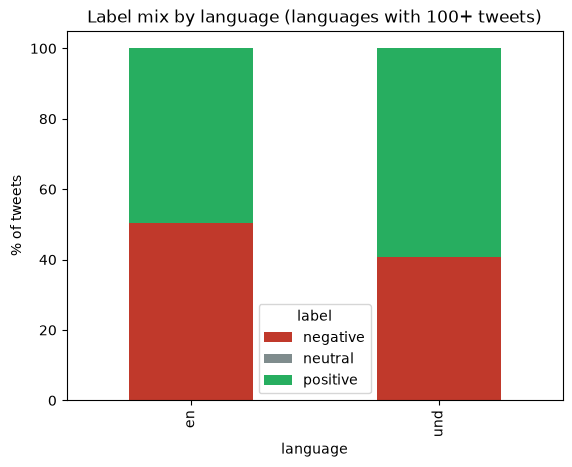

In [6]:
mix = (pd.crosstab(df['language'], df['label'], normalize='index') * 100).round(1)
mix['tweets'] = df['language'].value_counts()
print(mix.sort_values('tweets', ascending=False))
big = mix[mix['tweets'] >= 100].drop(columns='tweets')
big.plot.bar(stacked=True, color=['#c0392b', '#7f8c8d', '#27ae60'], title='Label mix by language (languages with 100+ tweets)')
plt.ylabel('% of tweets'); plt.show()

## Code-switching candidates
`is_code_switched` is a **candidate flag** tuned for precision. Expect false alarms (names, slang). Real mixed Afrikaans/English text will come from the Namibia sample.

In [7]:
print(df['is_code_switched'].sum(), 'candidates')
df[df['is_code_switched']][['text_clean', 'languages_found']].head(10)

317 candidates


,text_clean,languages_found
4,i really don't know. i think its Globe! yeah! sana gumaling na ko para alam ko na din kung makakasama ako! ),tl|en
6,yayyy! lol. i just requested herrr. what did she say?,en|xh
75,Good morning to all followers. I wish you a nice Tuesday and good luck with your business. | Allen Verfolg...,en|de
251,"[uk] It's hard to tweet [dk] ""I dag har Anders f dselsdag.."" [dk] within just 140 characters",da|en
699,Haha whaaat?! A boys club? In architecture?! :O (That's me pretending to be shocked),en|mi
898,how things so far ? You like Indian food ? or you the scardy types Go have a masala dosa for breakfast.,en|ms
1060,grindin grindin grindinnnn...tryna finish the massive amount of designs i already have to do so i can star...,en|lt
1386,"Thats cool, i wish i could write like that. Oh wait,.. I can. Heygirlimturningtwitteroffnow.textmeback. Haha",en|tl
3247,ive never had a successful ride/run with the iphone mapmyrun or runkingpro or whatever it is. always stops...,en|nn
3463,Die Schulferien sind vorbei... Why do all good things come to an end...?,en|de


## Final quality check

In [8]:
checks = {
    'rows': len(df),
    'duplicate tweet_id': int(df['tweet_id'].duplicated().sum()),
    'nulls in key columns': int(df[['tweet_id', 'created_at', 'label', 'text_clean', 'language']].isna().sum().sum()),
    'date range': f"{df['created_at'].min():%Y-%m-%d} -> {df['created_at'].max():%Y-%m-%d}",
    'label_source': df['label_source'].value_counts().to_dict(),
}
checks

{'rows': 100493,
 'duplicate tweet_id': 0,
 'nulls in key columns': 0,
 'date range': '2009-04-07 -> 2009-06-25',
 'label_source': {'emoticon': 100000, 'manual': 493}}

## What we did and why
Language columns let Req 2/3/7/8 split results by language and stop non-English or too-short text from silently skewing them.
**The final dataset is `data/processed/nampulse_clean.parquet` (and `.csv`). Column meanings are in the README.**

Limitations to remember: mostly English, Oshiwambo is unsupported by any common detector, emoticon labels are noisy, and the code-switch flag needs manual review.